## Dataset Demo

The objective this demo is to demonstrate how does the raw data look like, and produce figures for the pre-processing section of the paper.

In [3]:
%reload_ext autoreload
%autoreload 2
import os
import numpy as np
import utils
import seaborn as sea
from dataset_preparation import *
import matplotlib.pyplot as plt

### Step 1. Plot IQ samples from the raw dataset

Note: highlight IQ samples from a single preamble for Step 2.
Note: for this task, we're going to be using a single file from S3 bucket (manually downloaded): 

/mobintel-orbit-dataset/orbit_experiment_aug_8/epoch_2024-08-08_19-19-27/tx{node_node1-11}_rx{node_node1-1+rxFreq_2462e6+rxGain_10+capLen_4+rxSampRate_25e6}.dat

Since frame detection module is implemented in Matlab, for simplicity we will re-set indexes of the first frame:

index_start: 210024<br>
index_end: 210424

/home/smazokha2016/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/smazokha2016/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


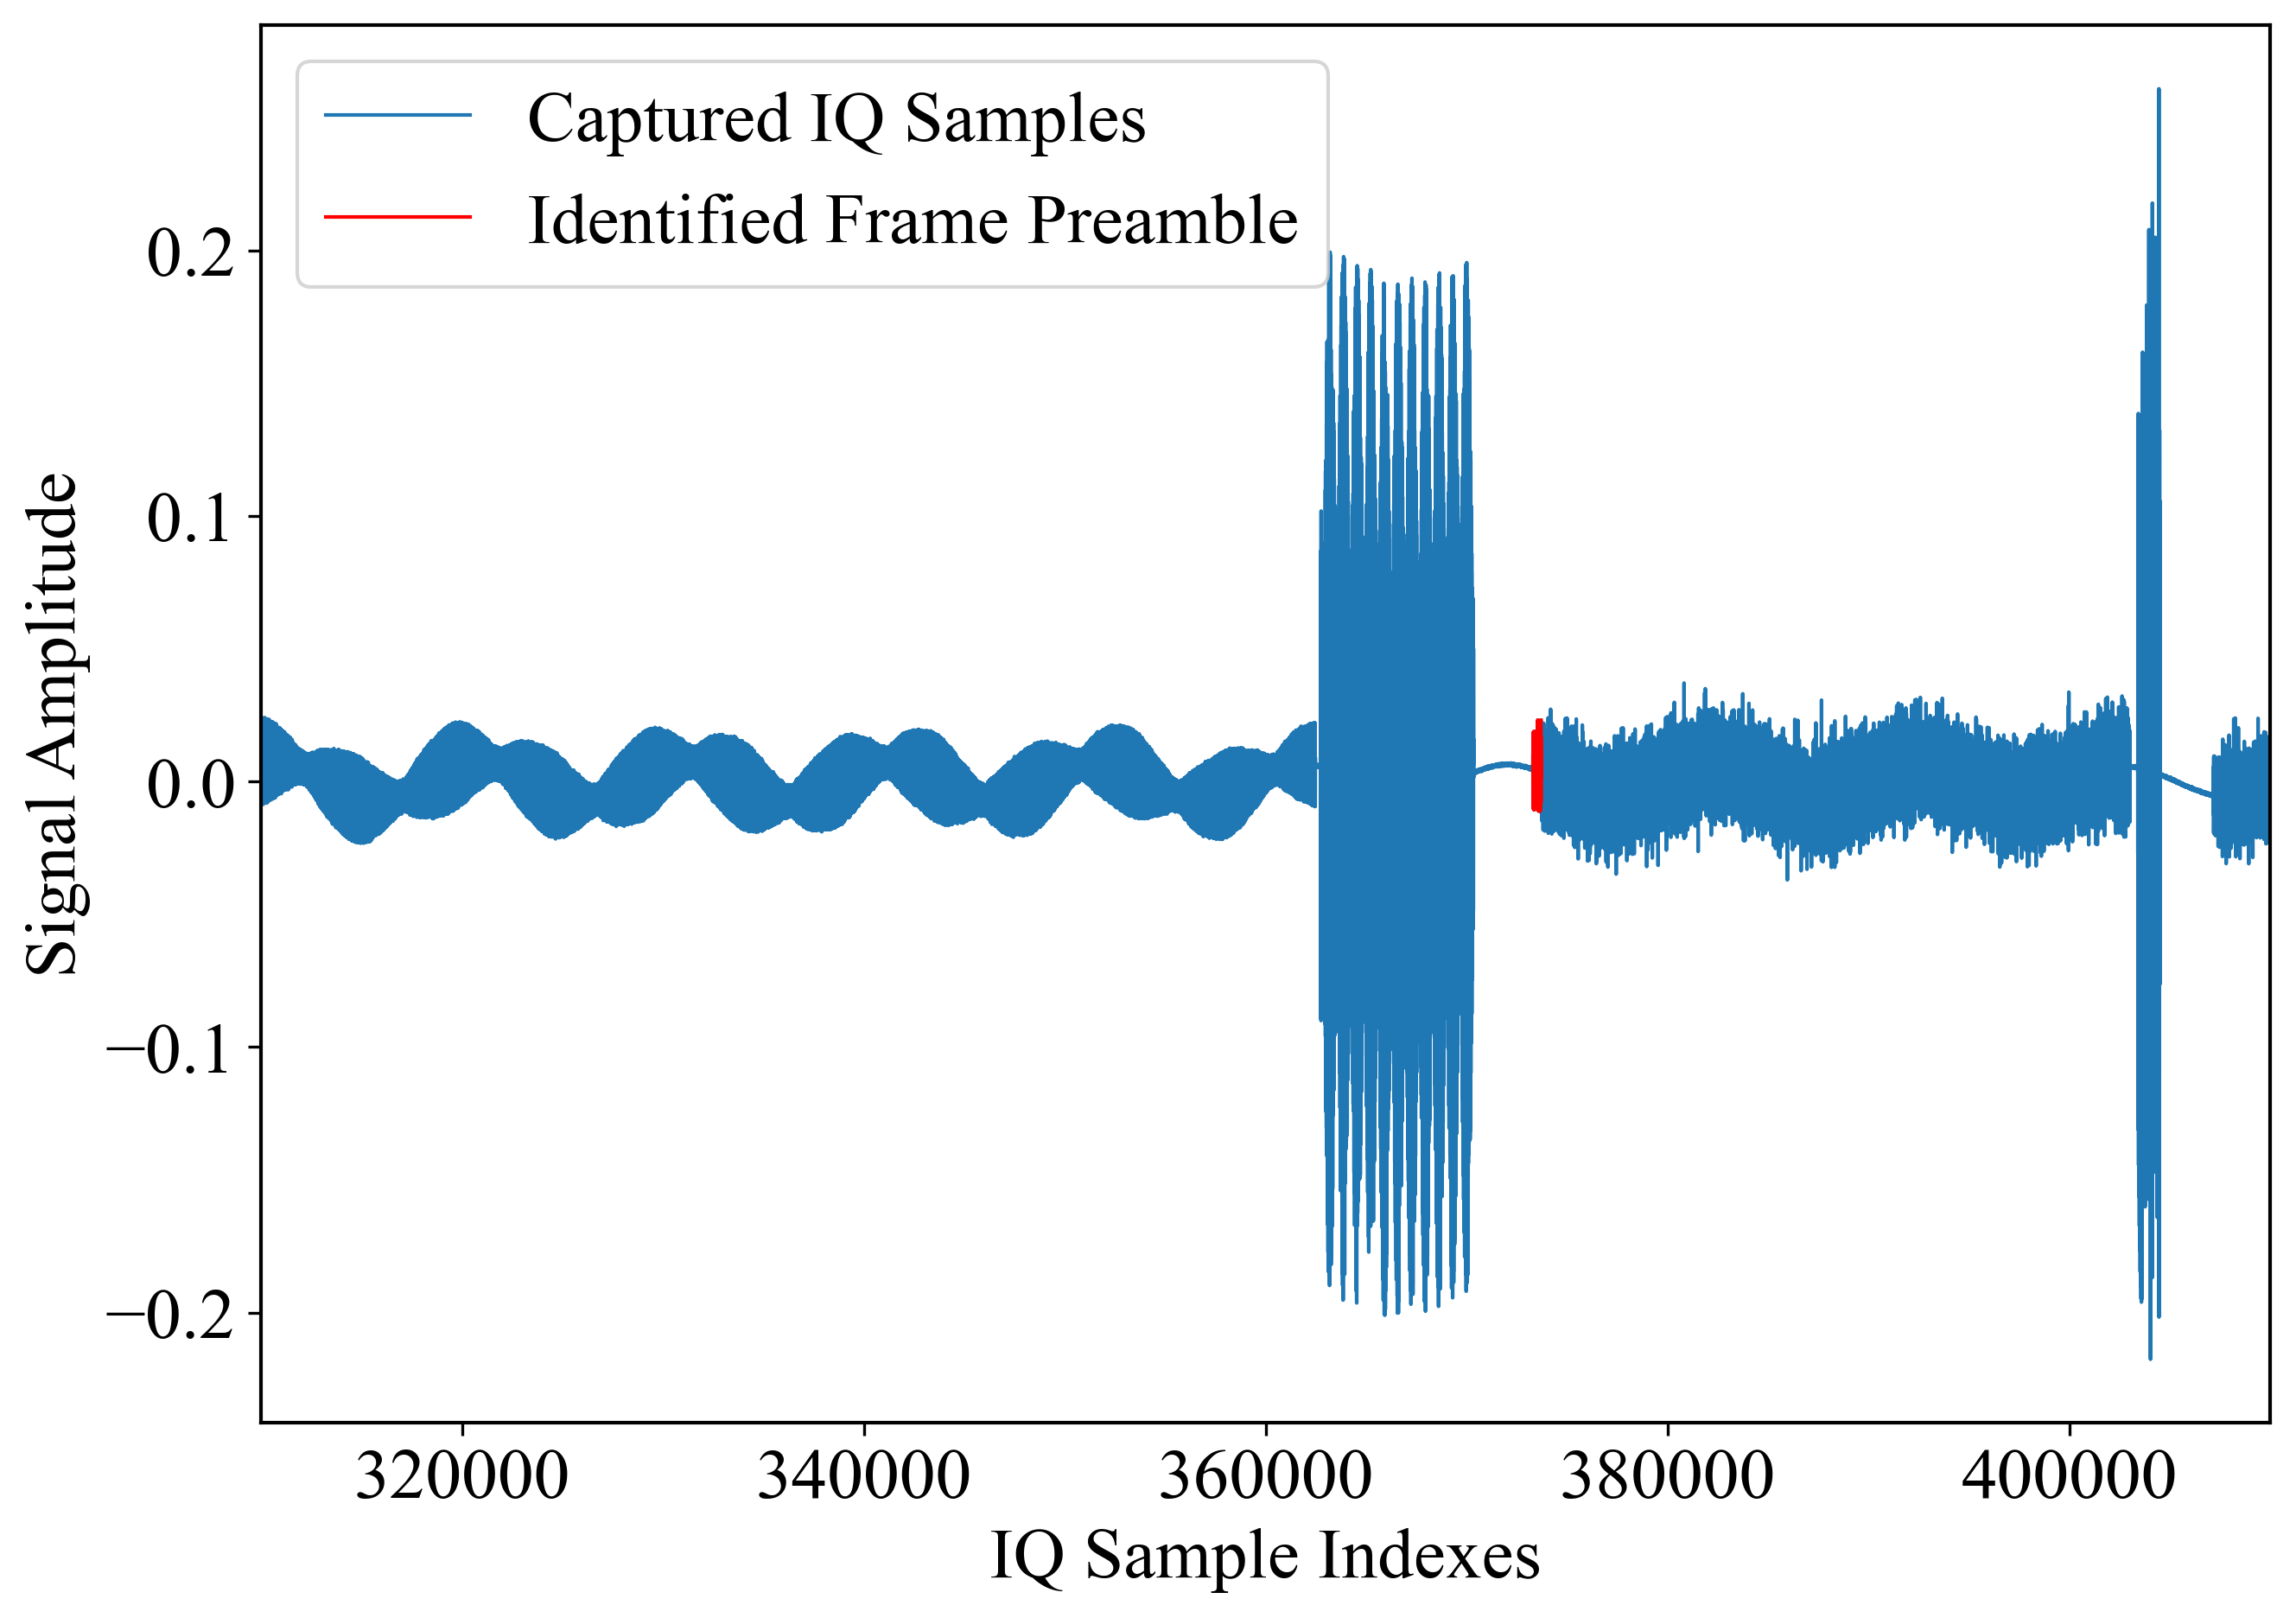

In [4]:
# preamble_1_idx = np.arange(210024, 210424)
# preamble_2_idx = np.arange(611010, 611410)
# preamble_3_idx = np.arange(700000, 700400)

preamble_1_idx = np.arange(8681, 9080)
preamble_2_idx = np.arange(373309, 373708)
preamble_3_idx = np.arange(407175, 407574)

ROOT_DIR = '/home/smazokha2016/Desktop/orbit_dataset_v3_aug8/raw_dataset_demo'
# FILE_PATH = 'tx{node_node1-11}_rx{node_node1-20+rxFreq_2462e6+rxGain_10+capLen_4+rxSampRate_25e6}.dat'
FILE_PATH = 'tx{node_node2-1}_rx{node_node1-1+rxFreq_2462e6+rxGain_10+capLen_4+rxSampRate_25e6}.dat'
iq = utils.read_dat_iq_file(os.path.join(ROOT_DIR, FILE_PATH))

preamble_1 = iq[preamble_1_idx]
preamble_2 = iq[preamble_2_idx]
preamble_3 = iq[preamble_3_idx]

utils.apply_ieee_style()
plt.figure(figsize=(10, 7), dpi=300)
plt.rcParams.update({'font.size': 20})
plt.tight_layout()
# plt.plot(iq[200000:300000])
# plt.plot(preamble_1_idx-200000, preamble_1, 'red')

iq_range = np.arange(310000, 410000)
plt.plot(iq_range, iq[iq_range], label='Captured IQ Samples')
plt.plot(preamble_2_idx, preamble_2, 'red', label='Identified Frame Preamble')
plt.xlim([min(iq_range), max(iq_range)])
plt.xlabel('IQ Sample Indexes')
plt.ylabel('Signal Amplitude')
plt.legend()

### Step 2. Plot IQ samples of a single preamble



/home/smazokha2016/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/smazokha2016/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Signal Amplitude')

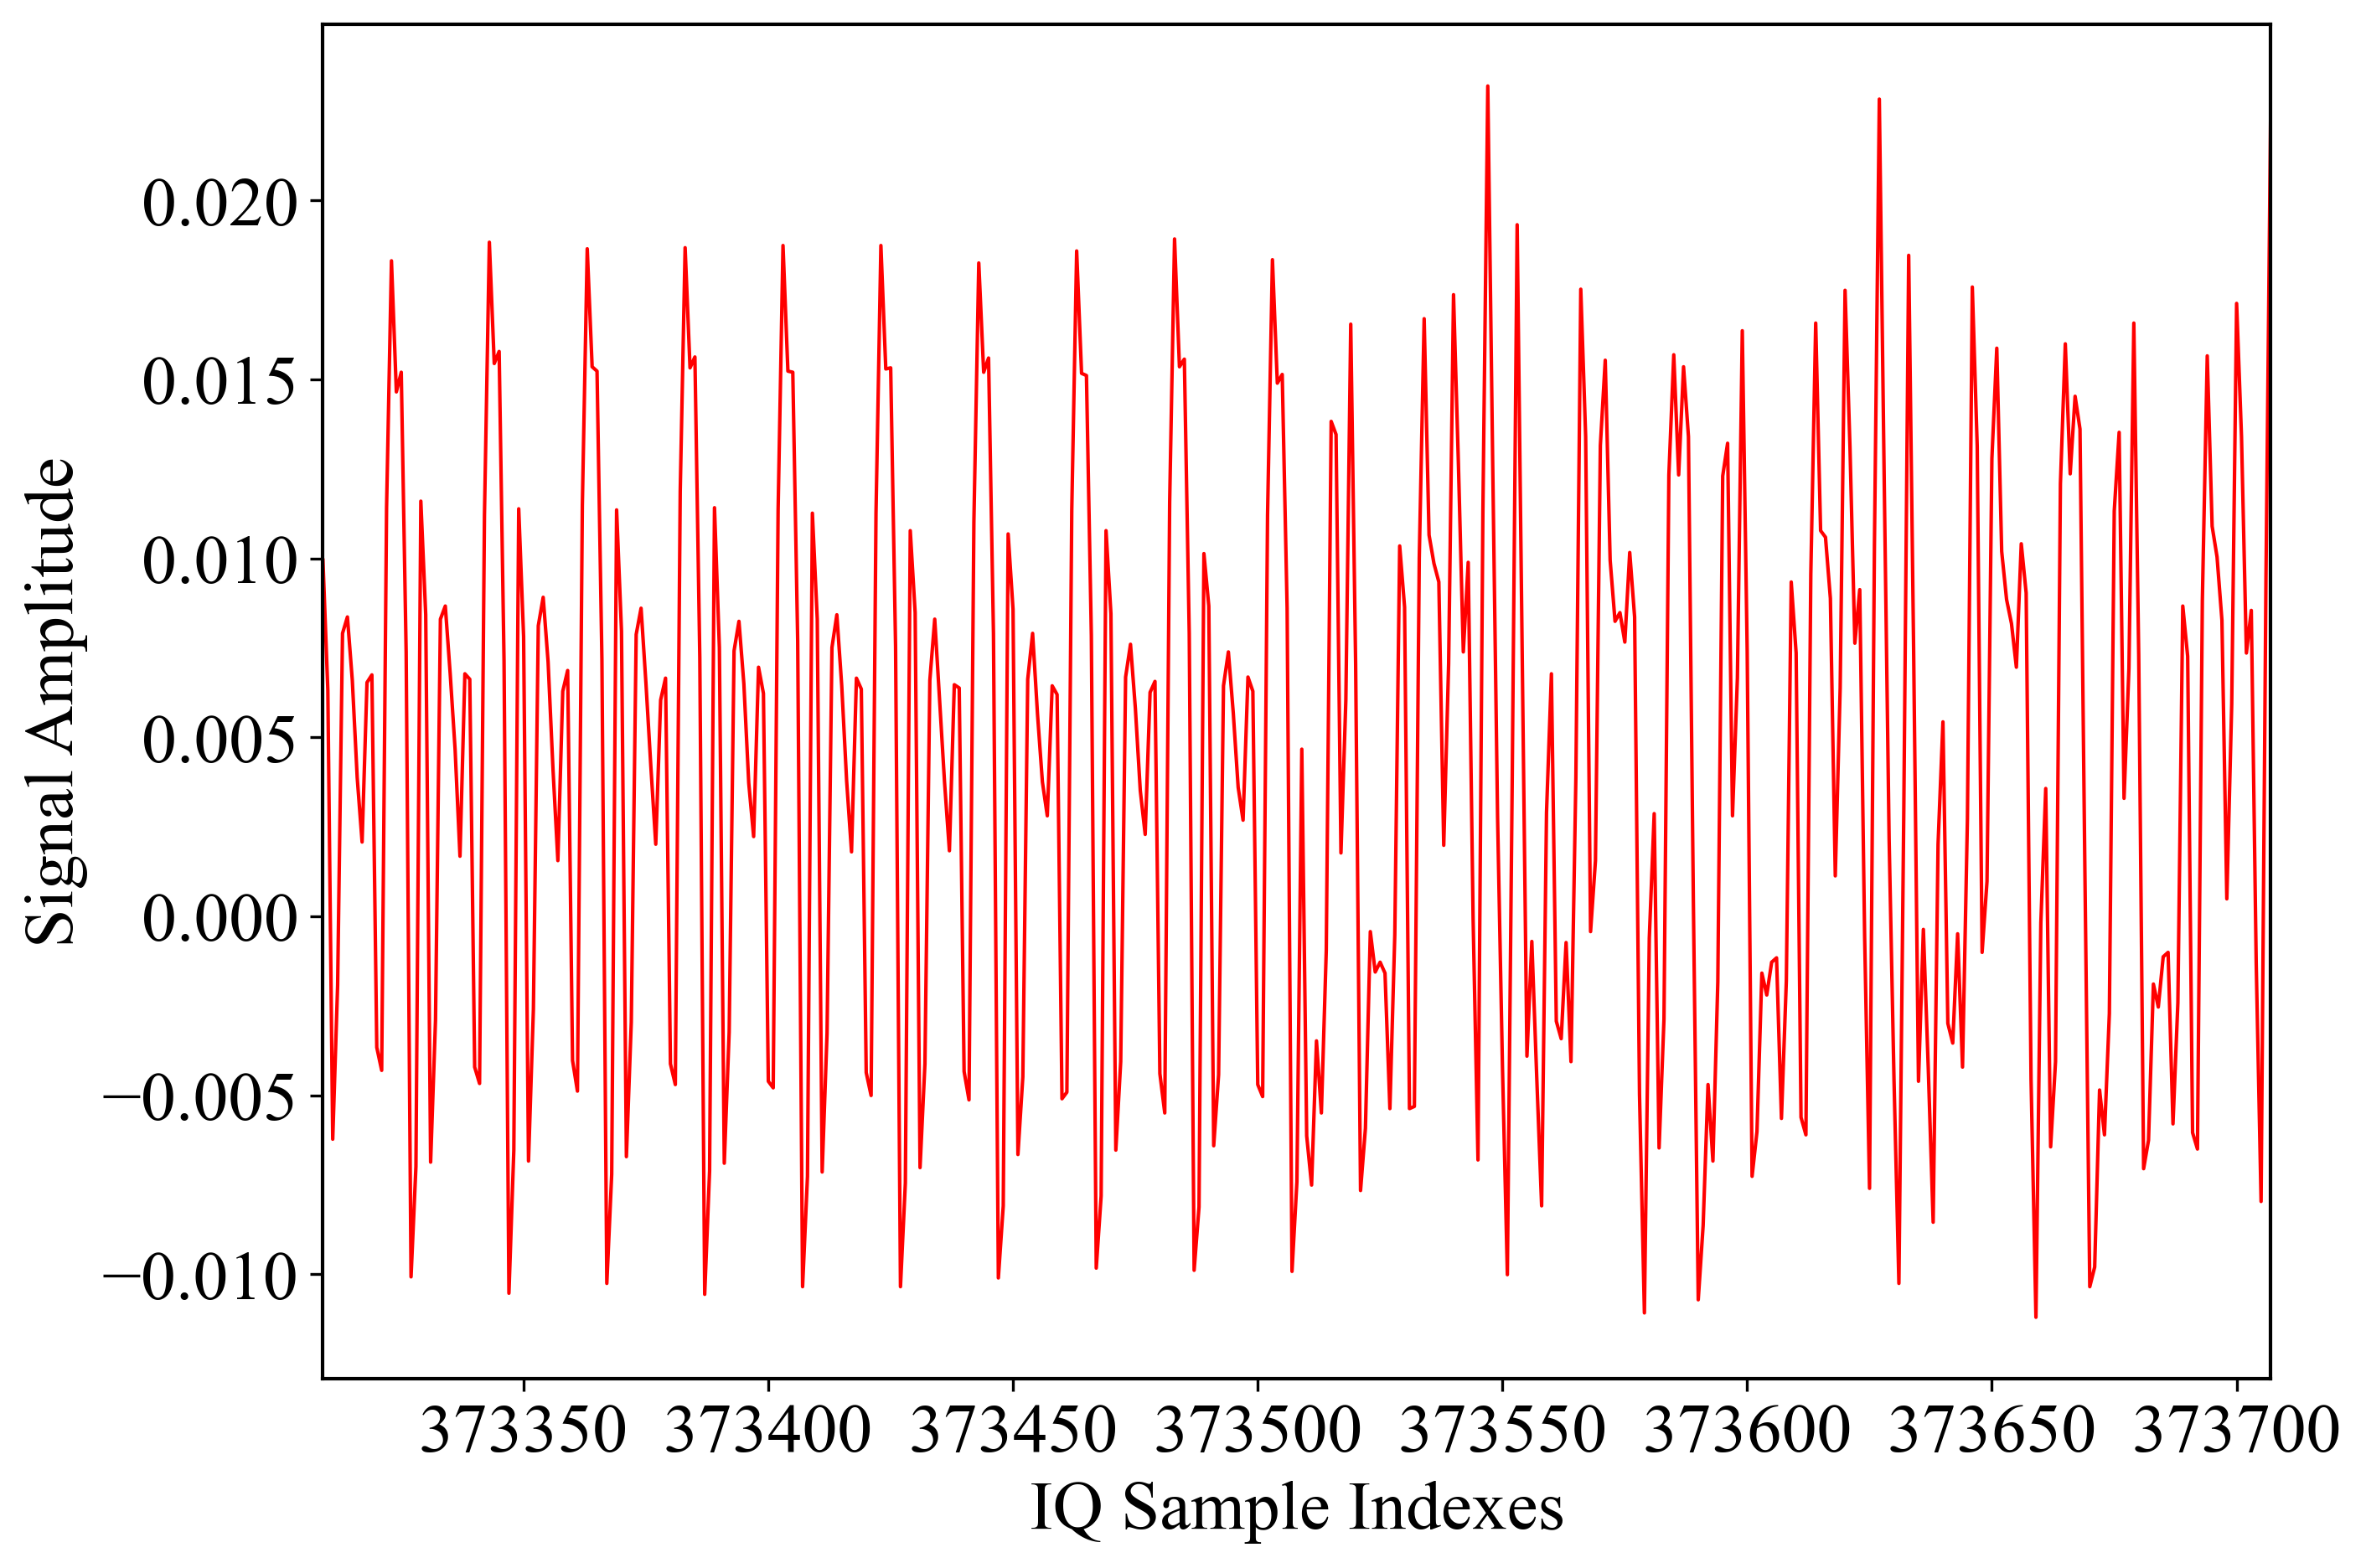

In [5]:
utils.apply_ieee_style()
plt.figure(figsize=(10, 7), dpi=300)
plt.rcParams.update({'font.size': 20})
plt.tight_layout()
plt.plot(preamble_2_idx, preamble_2, 'red')
plt.xlim([min(preamble_2_idx), max(preamble_2_idx)])

plt.xlabel('IQ Sample Indexes')
plt.ylabel('Signal Amplitude')

### Step 3. Run the pre-processing pipeline and demonstrate STFT result

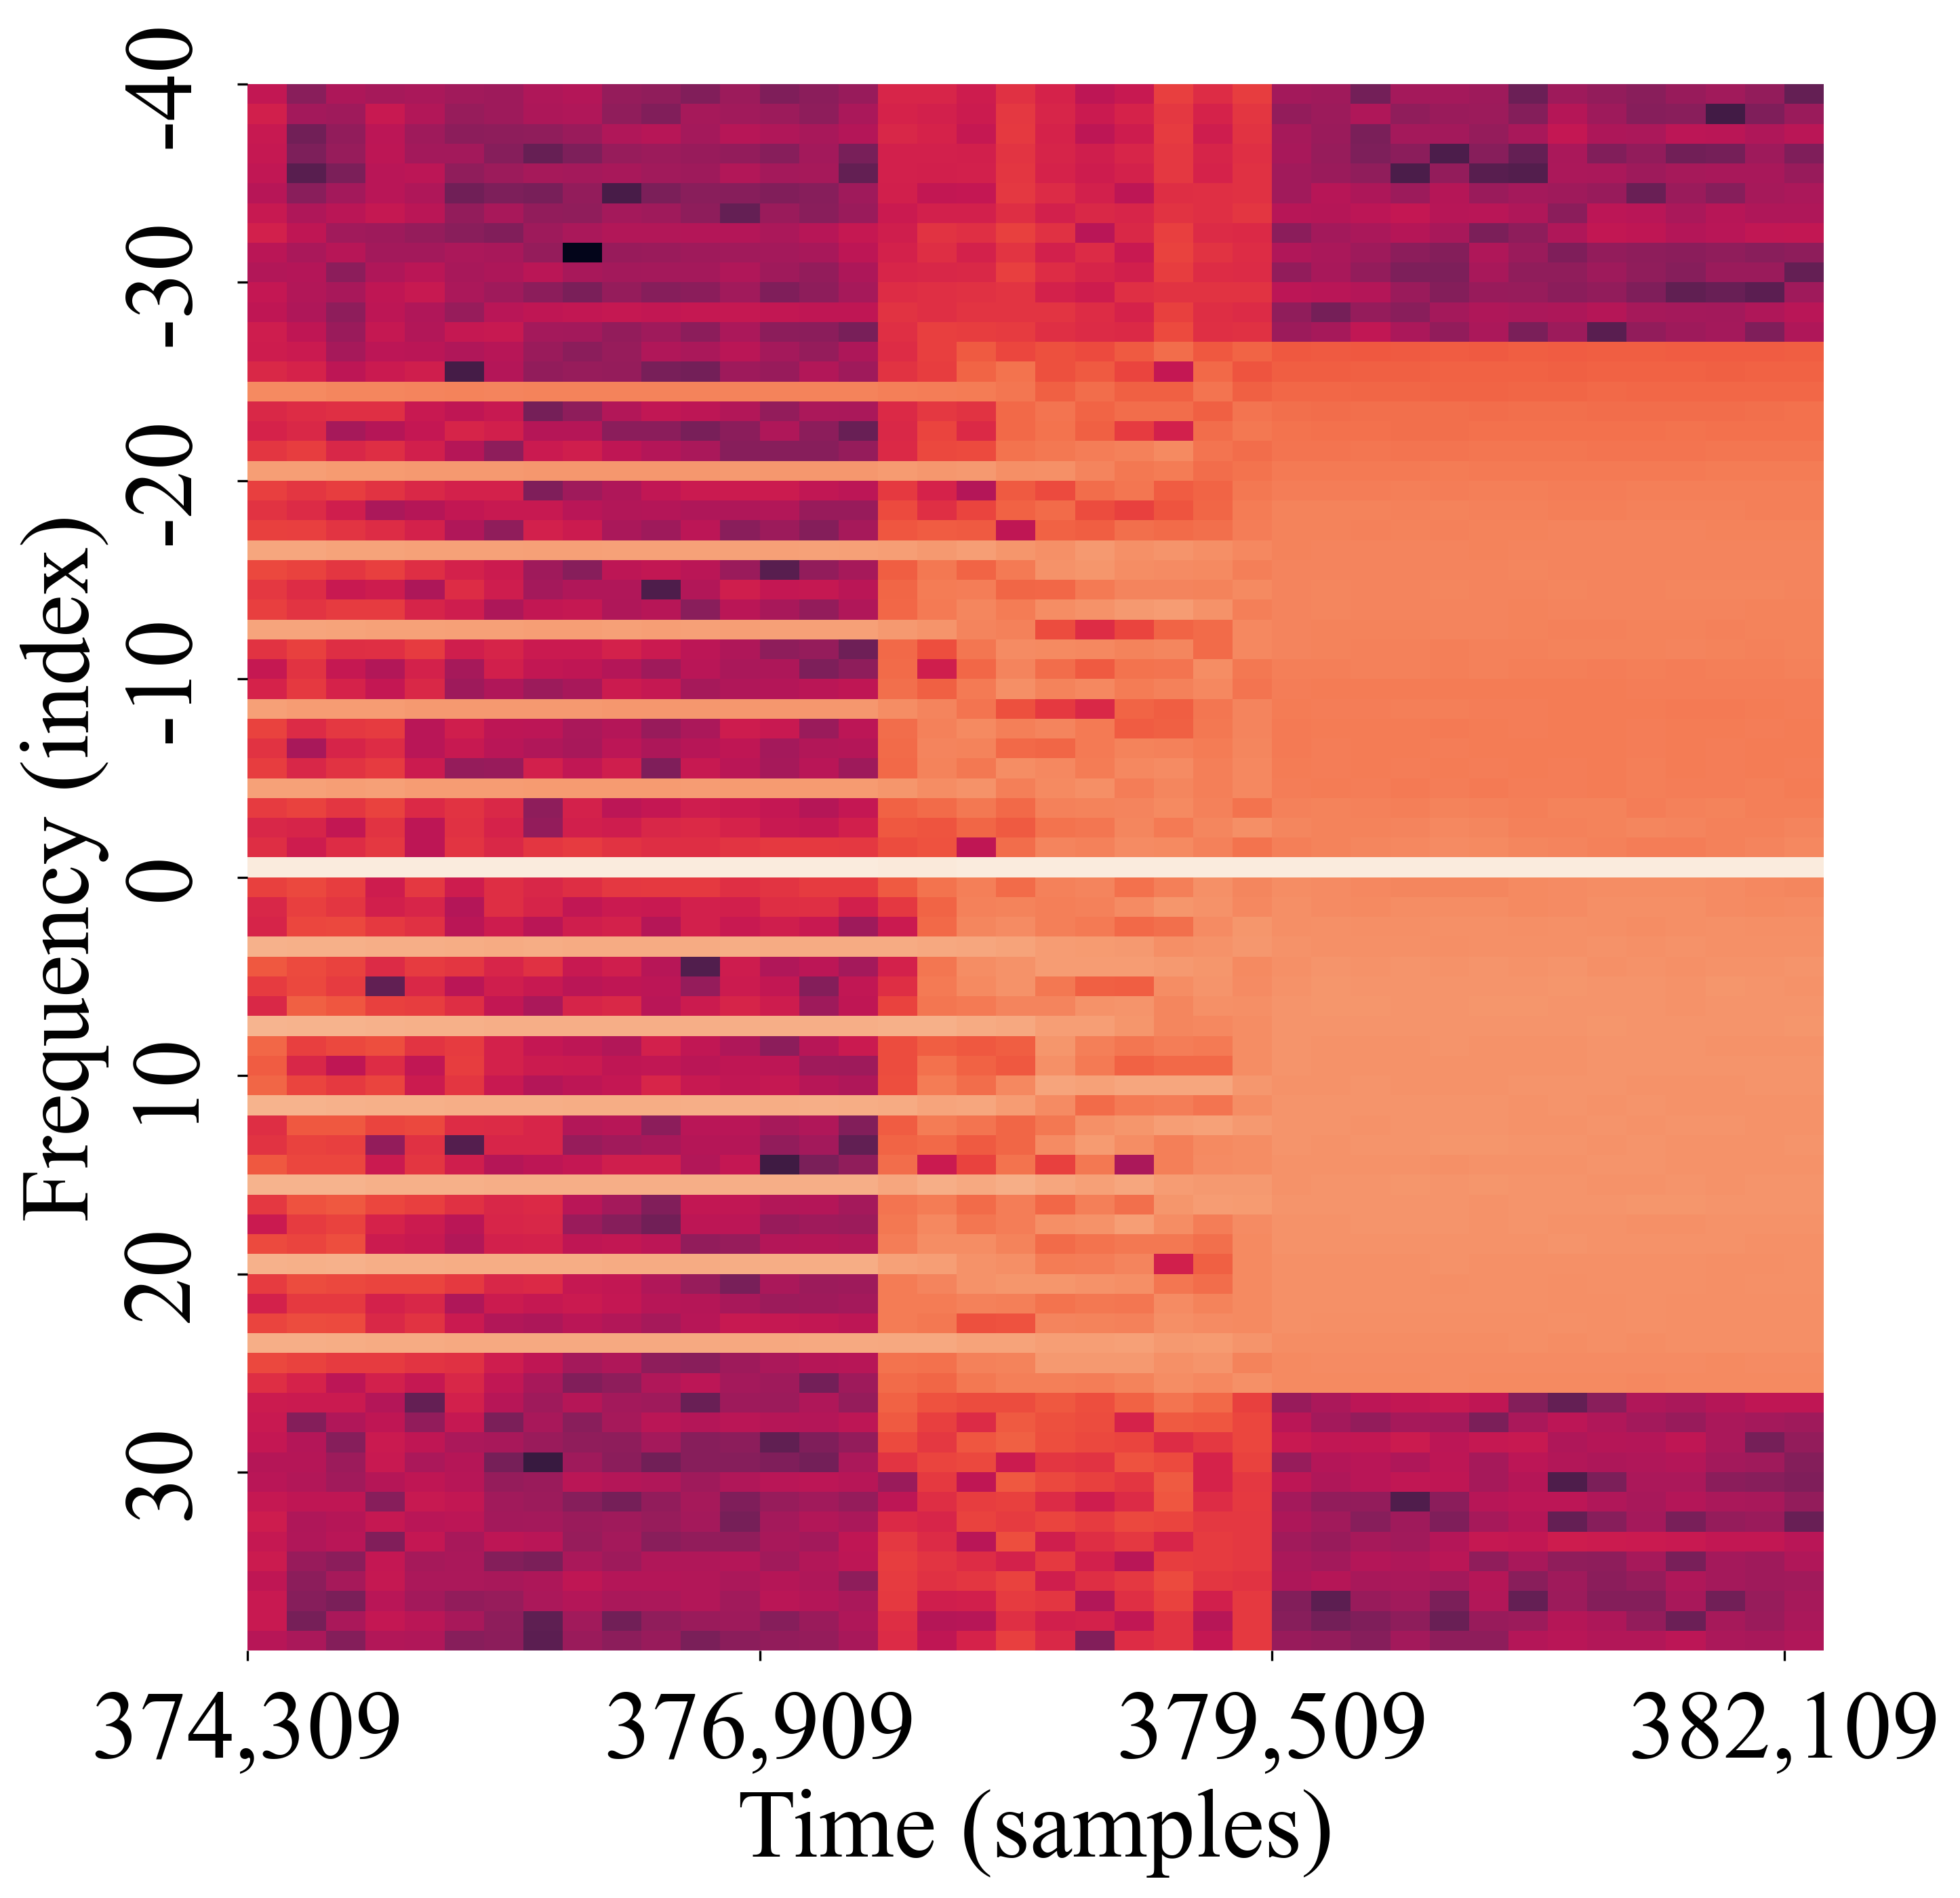

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea
from scipy import signal
from dataset_preparation import ChannelIndSpectrogram

def plot_spec_heatmap(spec, t, win_len, y_ticks, y_labels):
    # Plot the heatmap
    plt.figure(figsize=(10, 10), dpi=300)
    plt.rcParams.update({'font.size': 34})
    plt.tight_layout()

    # Create heatmap
    sea.heatmap(spec.squeeze()[1:, :], cbar=False)

    # Set X-axis (Time) labels
    start_index = min(preamble_2_idx)  # Starting point of your IQ samples
    time_ticks = np.linspace(0, len(t)-1, 4).astype(int)  # Select 5 evenly spaced time bins
    time_labels = [f"{item:,.0f}" for item in (start_index + np.round(t[time_ticks] * 25)).astype(int)]
    plt.xticks(ticks=time_ticks, labels=time_labels)  # Adjust time labels

    # Set Y-axis (Frequency) labels
    freq_bins = np.fft.fftshift(np.fft.fftfreq(win_len))  # Frequency indices
    freq_ticks = np.linspace(0, len(freq_bins)-1, 10).astype(int)  # Select 7 evenly spaced frequency bins
    plt.yticks(ticks=freq_ticks, labels=np.round(freq_bins[freq_ticks] * win_len).astype(int))
    plt.yticks(ticks=y_ticks, labels=y_labels)

    # Adjust the padding for the tick labels to avoid overlap
    plt.gca().tick_params(axis='x', pad=10)  # Increase padding for X-axis ticks
    plt.gca().tick_params(axis='y', pad=10)  # Increase padding for Y-axis ticks

    # Set axis labels
    plt.xlabel('Time (samples)')
    plt.ylabel('Frequency (index)')

    # Display the plot
    plt.show()

spec, t = ChannelIndSpectrogram().channel_ind_spectrogram(np.array([preamble_1]), row=80, enable_ind=False, remove_subcarriers=False, return_spec_t=True)
spec = spec[0, :, :, 0].squeeze()

plot_spec_heatmap(spec, t, win_len=80, y_ticks=np.arange(0, 80, 10), y_labels=np.arange(-40, 40, 10))

### Step 4. Remove guard and dc subcarriers

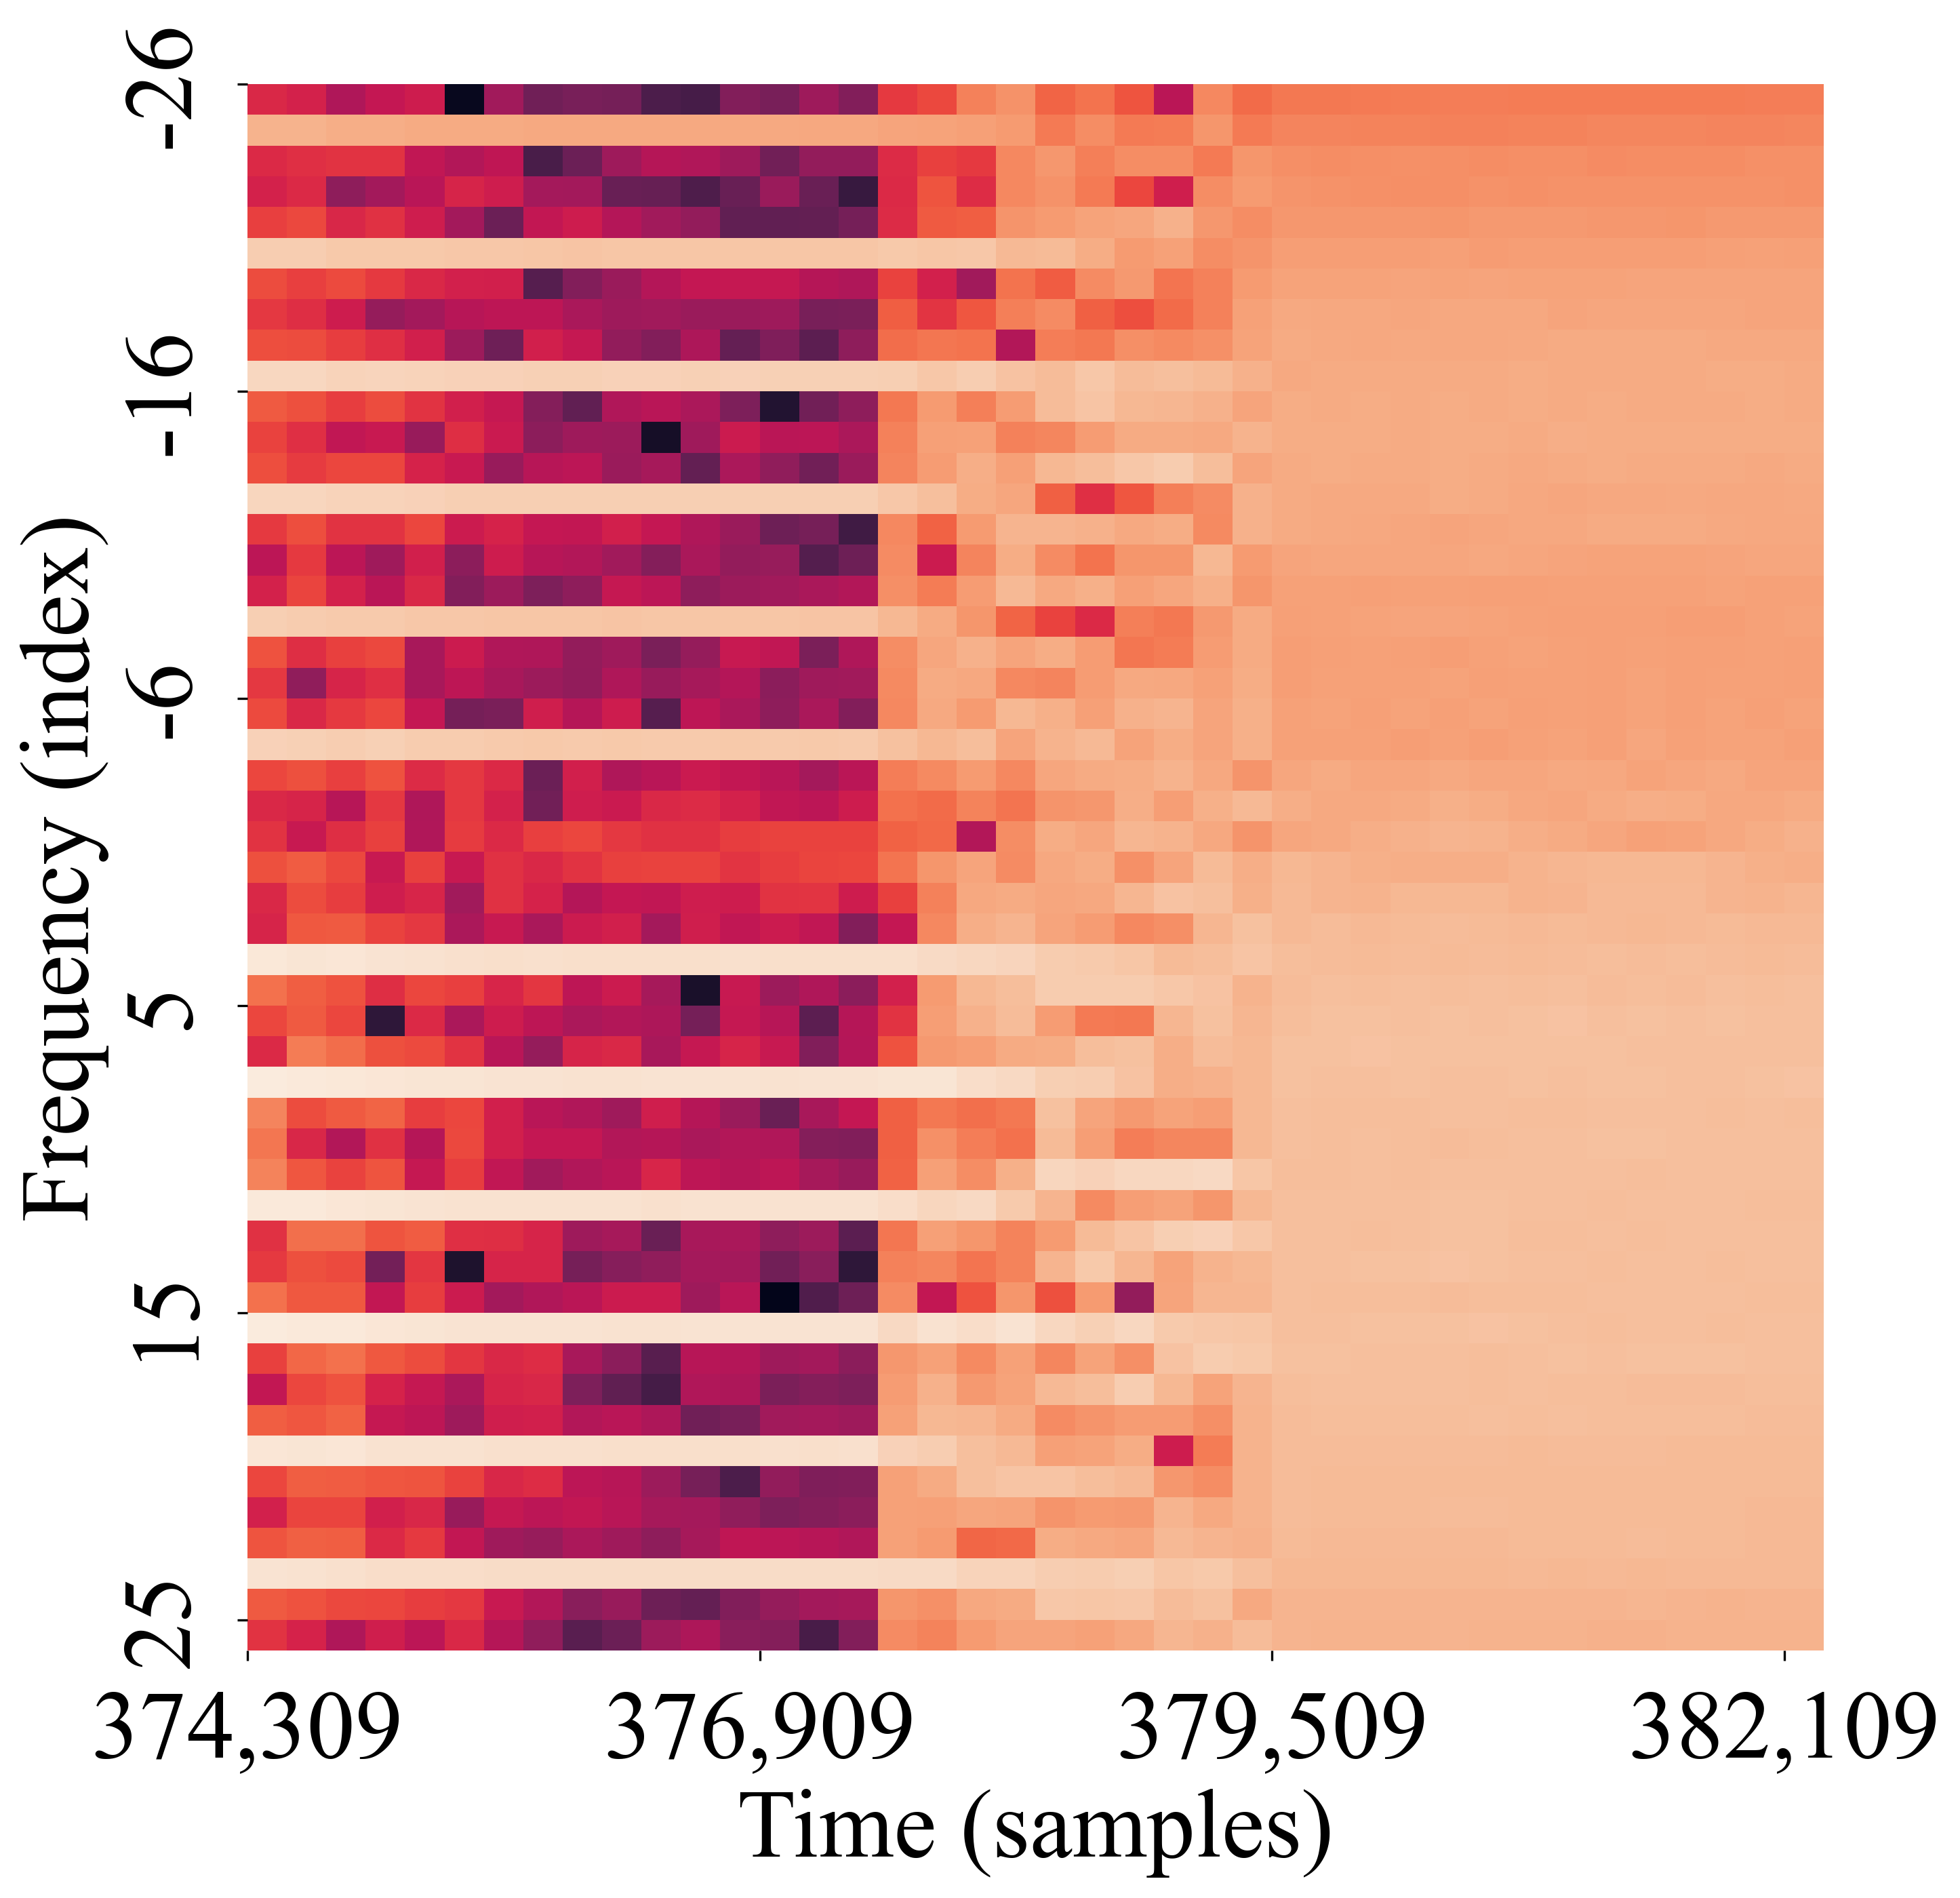

In [15]:
spec, t = ChannelIndSpectrogram().channel_ind_spectrogram(np.array([preamble_1]), row=80, enable_ind=False, remove_subcarriers=True, return_spec_t=True)
spec = spec[0, :, :, 0].squeeze()

guards = list(range(0, 14)) + [40] + list(range(67, 80))
y_ticks_labels = np.delete(np.arange(-40, 40), guards, axis=0)
y_ticks = np.arange(0, y_ticks_labels.shape[0], 10)

plot_spec_heatmap(spec, t, win_len=52, y_ticks=y_ticks, y_labels=y_ticks_labels[y_ticks])

### Step 4. Obtain channel-independent spectrogram & plot it as well

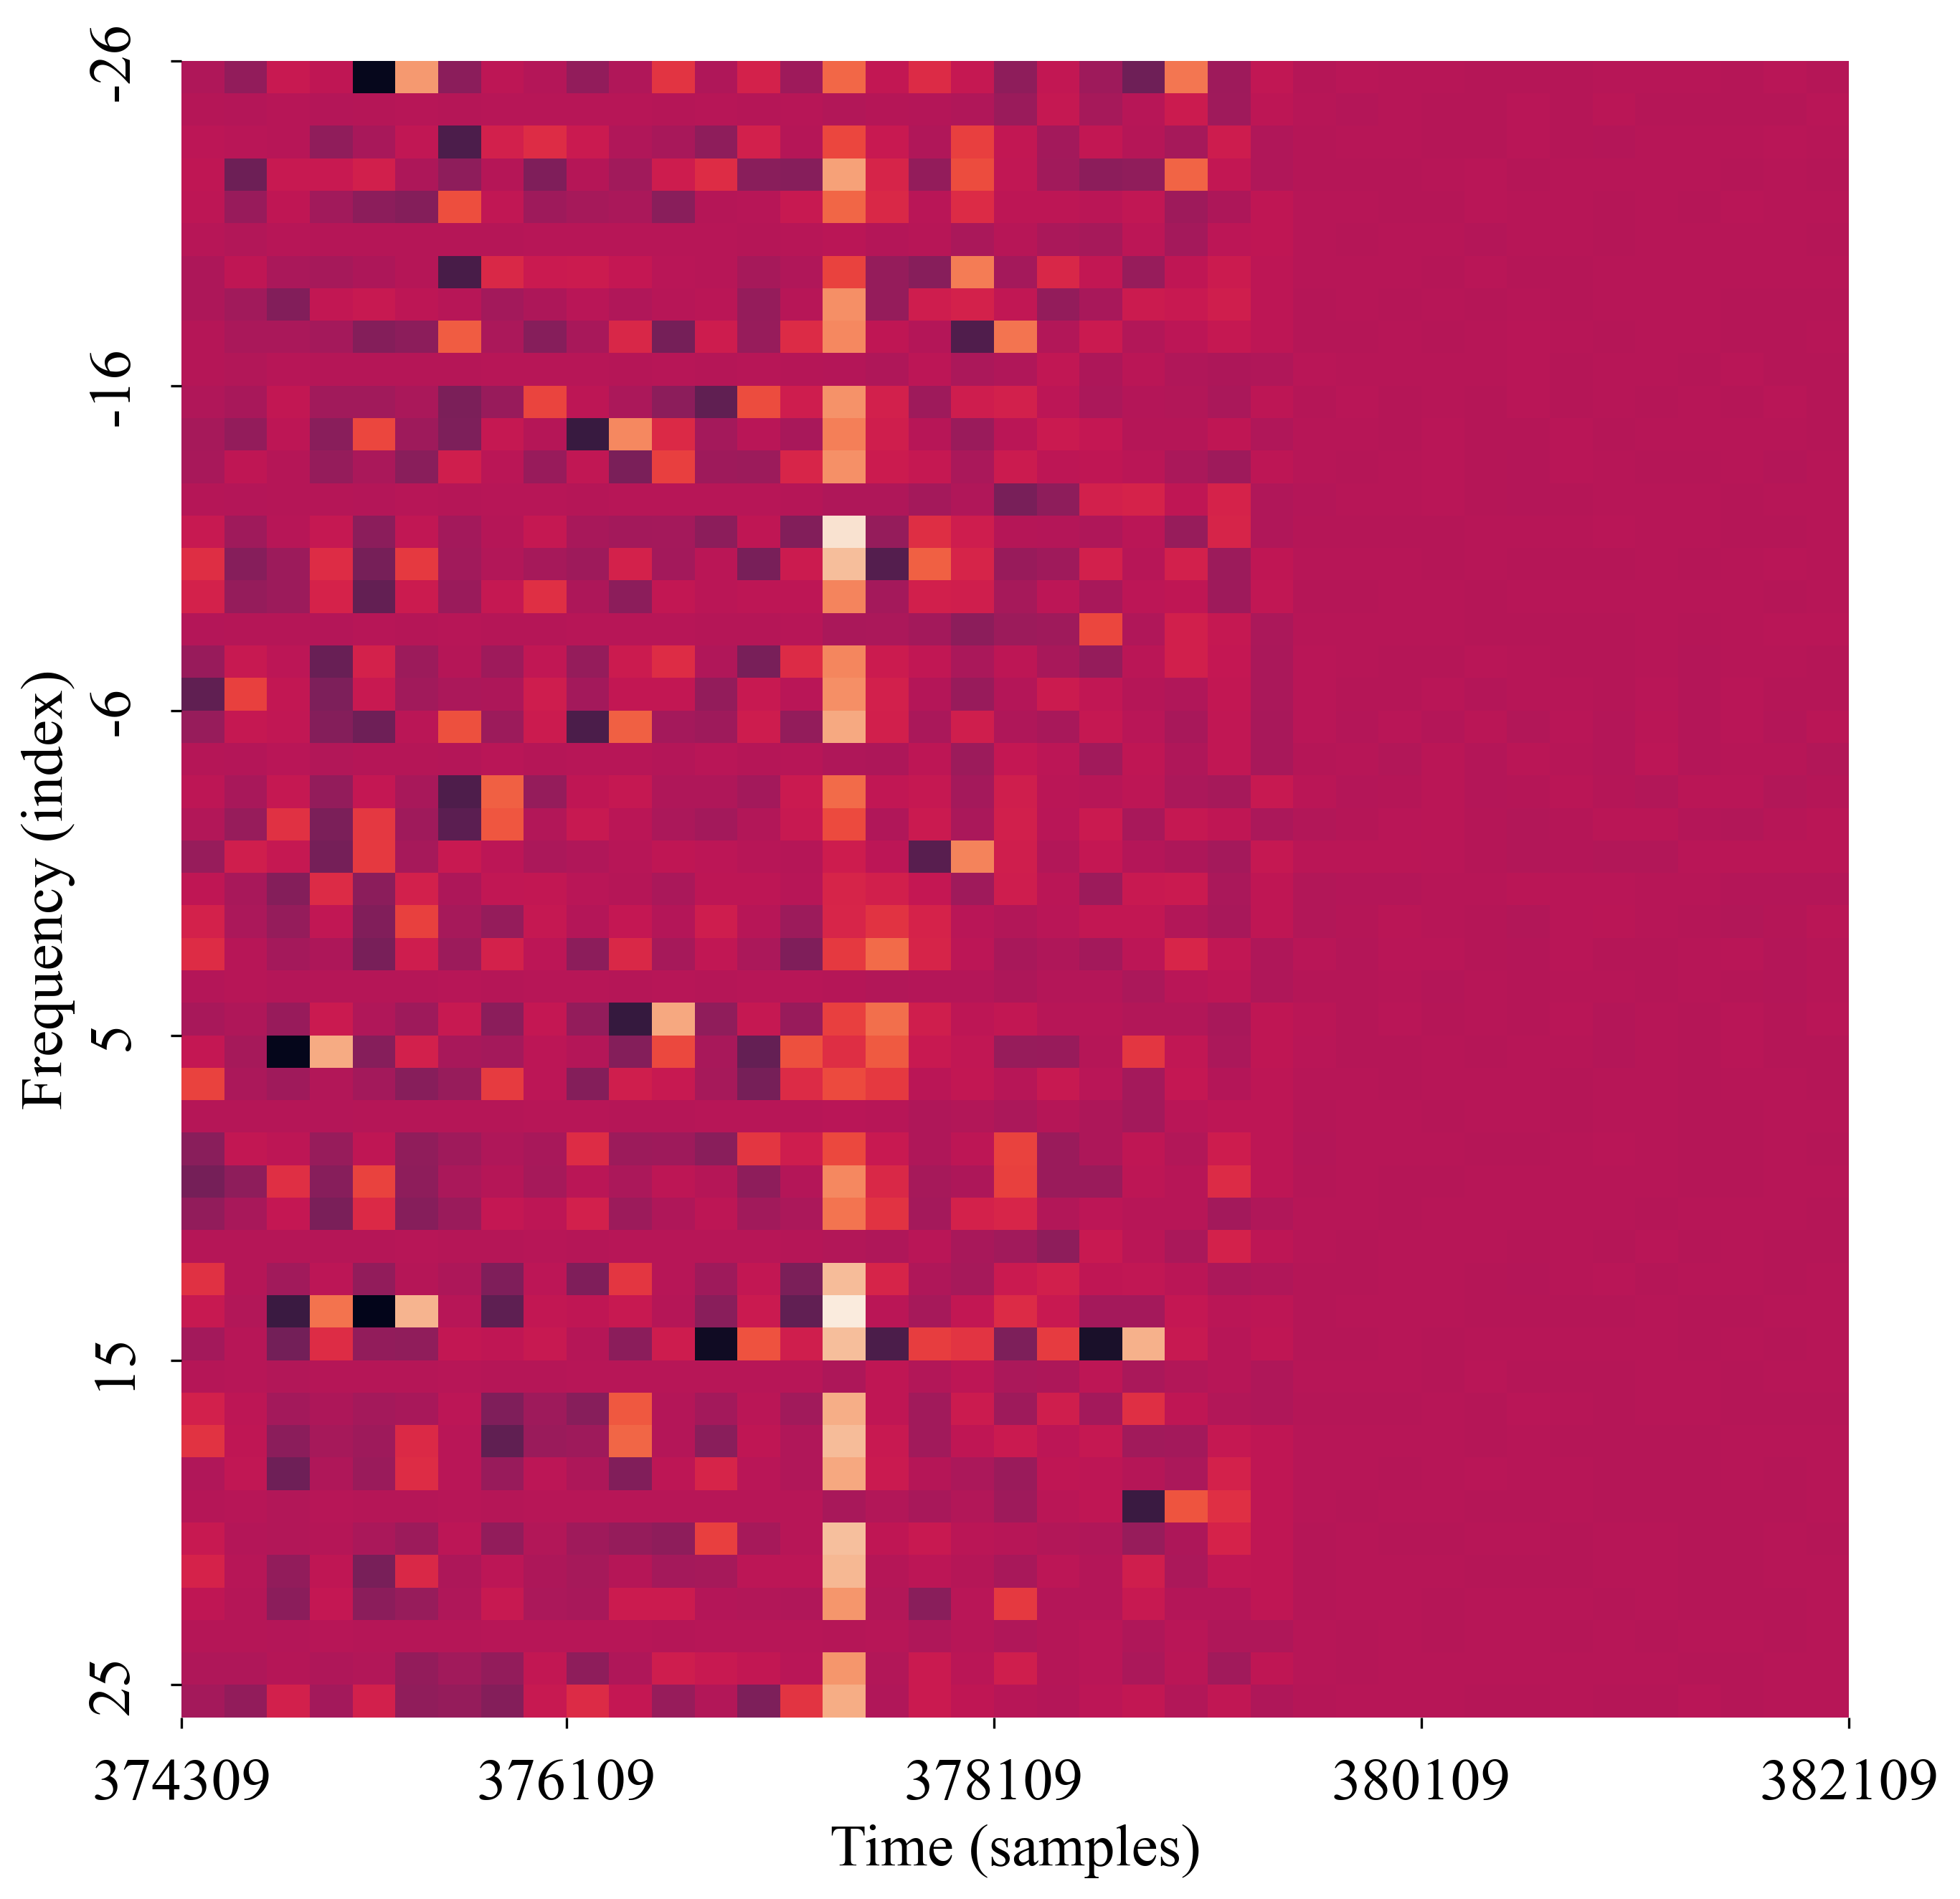

In [20]:
spec, t = ChannelIndSpectrogram().channel_ind_spectrogram(np.array([preamble_1]), row=80, enable_ind=True, remove_subcarriers=True, return_spec_t=True)
spec = spec[0, :, :, 0].squeeze()

guards = list(range(0, 14)) + [40] + list(range(67, 80))
y_ticks_labels = np.delete(np.arange(-40, 40), guards, axis=0)
y_ticks = np.arange(0, y_ticks_labels.shape[0], 10)

plot_spec_heatmap(spec, t, win_len=52, y_ticks=y_ticks, y_labels=y_ticks_labels[y_ticks])